# Kenya Disease Forecasting — Training Notebook (Malaria / TB / HIV)

This notebook trains **quantile regression models** (P10 / P50 / P90) that forecast
disease cases 1, 2, 3, and 6 months ahead, for each **county + disease + age group**
combination. It saves the trained models, EDA charts, and evaluation charts back to
your Google Drive so your backend can load them later.

**Contents:**
1. Setup & paths
2. Load data
3. EDA charts
4. Feature engineering (multi-horizon targets)
5. Train / validation / test split
6. **Model architecture**
7. Training loop (54 models)
8. **Evaluation** — metrics tables + graphs
9. Inference function (`forecast()`)
10. Forecast visualization
11. **Dashboard export** — writes `disease-monthly-data.json` in the exact
    shape your Next.js dashboard's `DiseaseMonthlyData` type expects
    (region-level, historical + forecast, ready for `lib/data/store.ts`)


In [2]:
# 1. Mount Google Drive and install/import libraries
# -----------------------------------------------------
# LightGBM ships with Colab already, but we pin-install to be safe.

from google.colab import drive
drive.mount('/content/drive')

!pip install lightgbm --quiet

import json
import os
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120


Mounted at /content/drive


In [3]:
# 2. Paths
# --------
# PATH        -> your input CSV (as you shared it)
# MODEL_DIR   -> where trained model files (.txt) + metadata (.json) are saved
# CHART_DIR   -> where EDA / evaluation PNG charts are saved
# All three live under the same project folder on Drive so everything
# stays together and your backend can just point at MODEL_DIR later.

PATH = Path(
    "/content/drive/MyDrive/SIP_AB/data/"
    "kenya_disease_forecasting_training_synthetic_2018_2025.csv"
)

PROJECT_DIR = Path("/content/drive/MyDrive/SIP_AB")
MODEL_DIR = PROJECT_DIR / "models"
CHART_DIR = PROJECT_DIR / "charts"
DASHBOARD_DIR = PROJECT_DIR / "dashboard_export"   # disease-monthly-data.json lands here

MODEL_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:    ", PATH, "-> exists:", PATH.exists())
print("Model dir:    ", MODEL_DIR)
print("Chart dir:    ", CHART_DIR)
print("Dashboard dir:", DASHBOARD_DIR)


Data path:     /content/drive/MyDrive/SIP_AB/data/kenya_disease_forecasting_training_synthetic_2018_2025.csv -> exists: True
Model dir:     /content/drive/MyDrive/SIP_AB/models
Chart dir:     /content/drive/MyDrive/SIP_AB/charts
Dashboard dir: /content/drive/MyDrive/SIP_AB/dashboard_export


In [4]:
# 3. Load data
# ------------
df = pd.read_csv(PATH, parse_dates=["month"])

print("Shape:", df.shape)
print("Date range:", df['month'].min().date(), "to", df['month'].max().date())
print("Counties:", df['county'].nunique())
print("Diseases:", df['disease'].unique().tolist())
print("Age groups:", sorted(df['age_group'].unique().tolist()))
df.head()


Shape: (433152, 34)
Date range: 2018-01-01 to 2025-12-01
Counties: 47
Diseases: ['HIV', 'Malaria', 'TB']
Age groups: ['0-4', '15-24', '25-34', '35-44', '45-54', '5-14', '55-64', '65+']


,month,year,month_of_year,county,synthetic_public_facility_group,disease,age_group,cases,population,age_group_population,...,same_month_last_year,same_month_2_years_ago,same_month_3_years_ago,cases_avg_prev_3m,cases_avg_prev_6m,cases_avg_prev_12m,pct_change_vs_previous_month,pct_change_vs_same_month_last_year,target_next_month_cases,target_next_month_pct_change
0,2018-01-01,2018,1,Baringo,1,HIV,0-4,0,1758807,228644,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,2018-02-01,2018,2,Baringo,1,HIV,0-4,0,1761301,228969,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.0,NaN
2,2018-03-01,2018,3,Baringo,1,HIV,0-4,0,1763799,229293,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.0,NaN
3,2018-04-01,2018,4,Baringo,1,HIV,0-4,0,1766300,229619,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,1.0,NaN
4,2018-05-01,2018,5,Baringo,1,HIV,0-4,1,1768805,229944,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,1.0,0.0


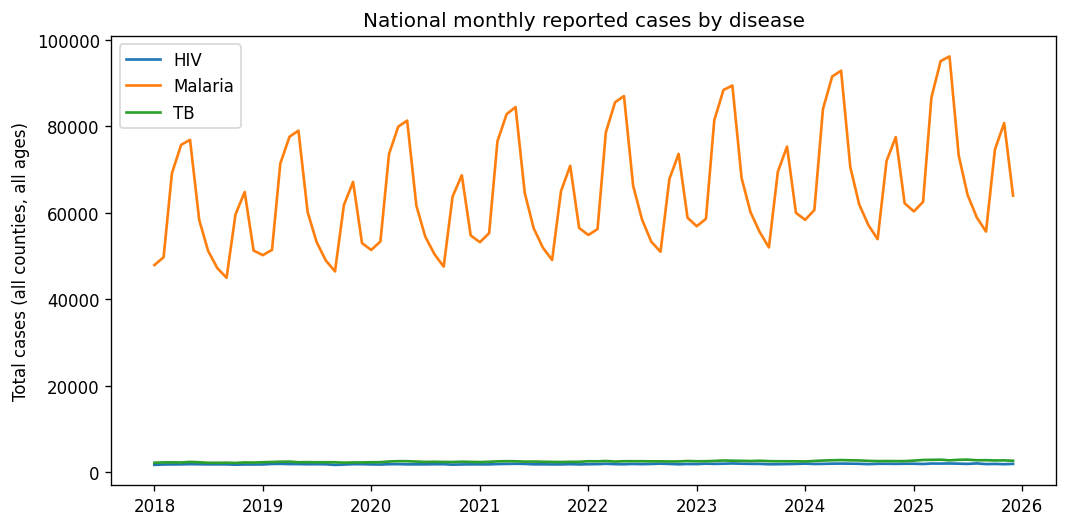

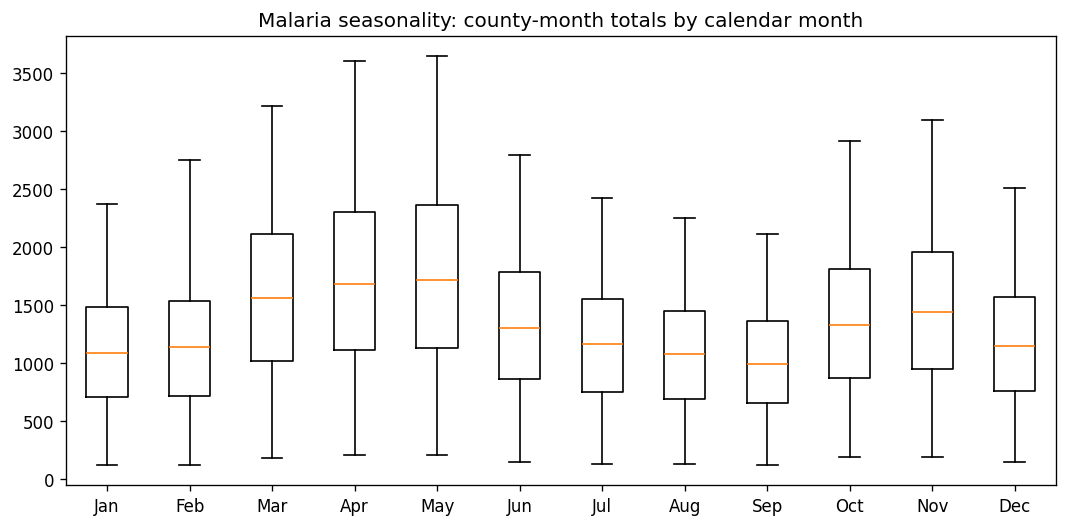

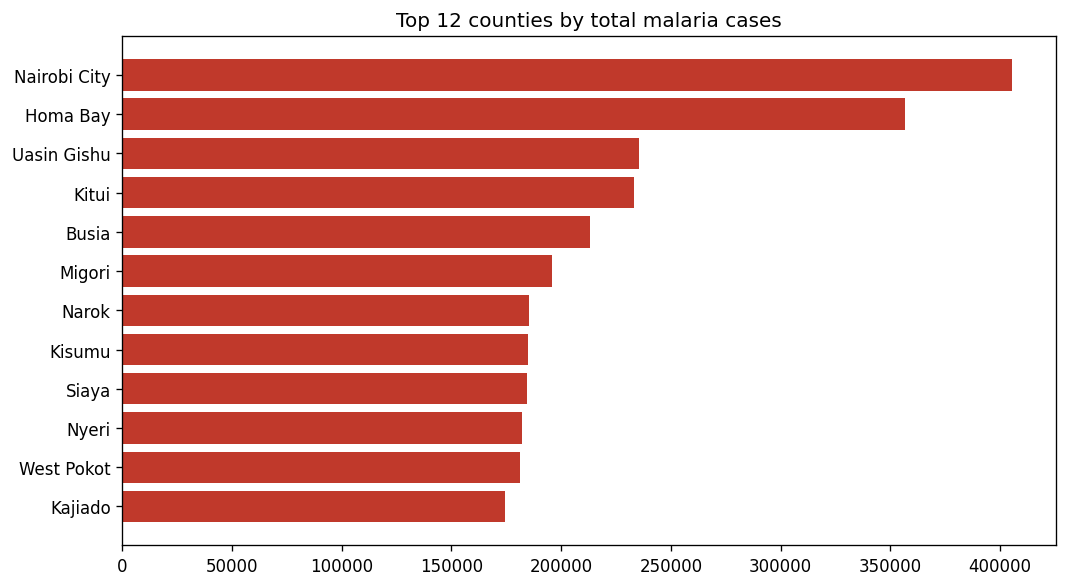

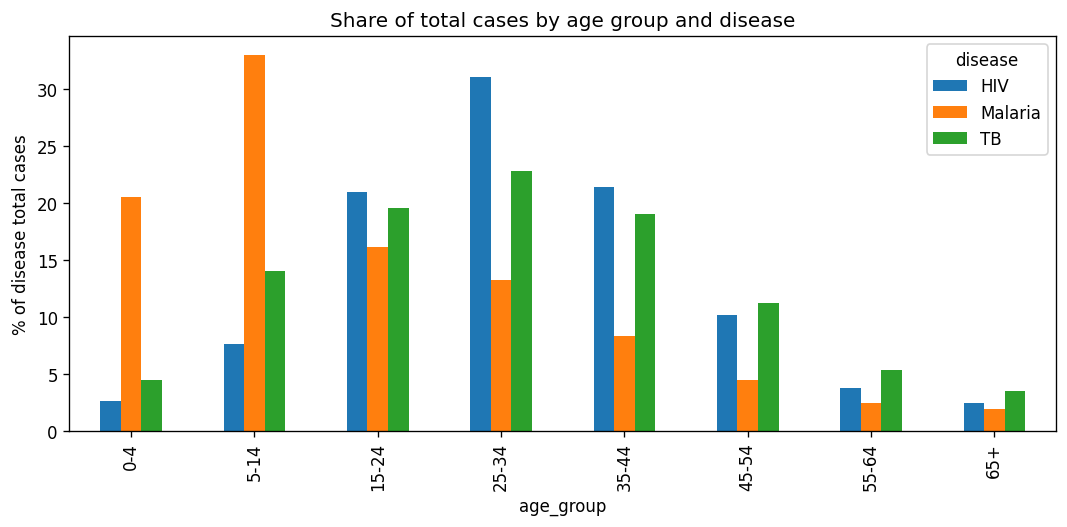

Saved 4 EDA charts to /content/drive/MyDrive/SIP_AB/charts


In [5]:
# 4. Quick EDA charts (saved to CHART_DIR)
# -----------------------------------------
# These give you a sanity check on the data before training, and are
# useful as-is for a project report or dashboard "about the data" page.

# --- Chart 1: national monthly trend per disease ---
monthly = df.groupby(['month', 'disease'])['cases'].sum().reset_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
for d, sub in monthly.groupby('disease'):
    ax.plot(sub['month'], sub['cases'], label=d, linewidth=1.6)
ax.set_title('National monthly reported cases by disease')
ax.set_ylabel('Total cases (all counties, all ages)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
fig.savefig(CHART_DIR / "01_national_trend.png")
plt.show()

# --- Chart 2: malaria seasonality by calendar month ---
mal = df[df.disease == 'Malaria'].groupby(['month', 'county'])['cases'].sum().reset_index()
mal['month_of_year'] = mal['month'].dt.month
fig, ax = plt.subplots(figsize=(9, 4.5))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.boxplot([mal[mal.month_of_year == m]['cases'] for m in range(1, 13)],
           tick_labels=month_labels, showfliers=False)
ax.set_title('Malaria seasonality: county-month totals by calendar month')
fig.tight_layout()
fig.savefig(CHART_DIR / "02_malaria_seasonality.png")
plt.show()

# --- Chart 3: top 12 counties by total malaria burden ---
top12 = df[df.disease == 'Malaria'].groupby('county')['cases'].sum().sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top12.index[::-1], top12.values[::-1], color='#c0392b')
ax.set_title('Top 12 counties by total malaria cases')
fig.tight_layout()
fig.savefig(CHART_DIR / "03_top_counties_malaria.png")
plt.show()

# --- Chart 4: age-group share of cases per disease ---
age_order = ['0-4','5-14','15-24','25-34','35-44','45-54','55-64','65+']
age = df.groupby(['disease', 'age_group'])['cases'].sum().reset_index()
pivot = age.pivot(index='age_group', columns='disease', values='cases').loc[age_order]
pivot_share = pivot.div(pivot.sum(axis=0), axis=1) * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot_share.plot(kind='bar', ax=ax)
ax.set_title('Share of total cases by age group and disease')
ax.set_ylabel('% of disease total cases')
fig.tight_layout()
fig.savefig(CHART_DIR / "04_age_distribution.png")
plt.show()

print("Saved 4 EDA charts to", CHART_DIR)


In [6]:
# 5. Feature engineering
# -----------------------
# (a) Build MULTI-HORIZON targets: for each (county, disease, age_group,
#     facility_group) time series, shift 'cases' backward by h months so
#     each row also knows "what actually happened h months later".
#     This lets us train a DIRECT model per horizon (1, 2, 3, 6 months)
#     instead of chaining 1-month predictions into each other, which
#     would compound errors.
#
# (b) Encode county / age_group as integers for LightGBM.
#
# (c) Define the feature list per disease: Malaria additionally gets the
#     climate features (rainfall, temperature, humidity, NDVI, flooding,
#     rainy season), TB/HIV rely on history + population + healthcare
#     capacity instead, since climate barely correlates with them.

GROUP_COLS = ['county', 'disease', 'age_group', 'synthetic_public_facility_group']
HORIZONS = [1, 2, 3, 4, 5, 6]     # months ahead we forecast -- consecutive 1-6
                                   # so the dashboard gets an unbroken 6-month
                                   # forecast line (not just 1/2/3/6 with gaps)
QUANTILES = {'p10': 0.10, 'p50': 0.50, 'p90': 0.90}

df = df.sort_values(GROUP_COLS + ['month']).reset_index(drop=True)

# (a) multi-horizon targets
for h in HORIZONS:
    df[f'target_h{h}'] = df.groupby(GROUP_COLS)['cases'].shift(-h)

# (b) categorical encoding (label map saved so the backend can reuse it)
label_maps = {}
for col in ['county', 'age_group']:
    cats = sorted(df[col].unique().tolist())
    label_maps[col] = {c: i for i, c in enumerate(cats)}
    df[f'{col}_enc'] = df[col].map(label_maps[col]).astype('int32')

with open(MODEL_DIR / "label_maps.json", "w") as f:
    json.dump(label_maps, f, indent=2)

# (c) feature sets per disease
BASE_FEATURES = [
    'month_of_year', 'county_enc', 'age_group_enc', 'synthetic_public_facility_group',
    'population', 'age_group_population', 'population_density',
    'public_hospitals', 'testing_sites', 'healthcare_worker_density',
    'cases',                       # cases in the CURRENT month (known at forecast time)
    'cases_lag_1m', 'cases_lag_2m', 'cases_lag_3m', 'cases_lag_6m',
    'same_month_last_year', 'same_month_2_years_ago', 'same_month_3_years_ago',
    'cases_avg_prev_3m', 'cases_avg_prev_6m', 'cases_avg_prev_12m',
]
CLIMATE_FEATURES = ['rainfall_mm', 'temperature_c', 'humidity_pct', 'ndvi', 'flood_indicator', 'rainy_season']

DISEASE_FEATURES = {
    'Malaria': BASE_FEATURES + CLIMATE_FEATURES,
    'TB': BASE_FEATURES,
    'HIV': BASE_FEATURES,
}

with open(MODEL_DIR / "feature_sets.json", "w") as f:
    json.dump(DISEASE_FEATURES, f, indent=2)

print("Multi-horizon targets created:", [f'target_h{h}' for h in HORIZONS])
print("Feature counts -> Malaria:", len(DISEASE_FEATURES['Malaria']),
      "| TB:", len(DISEASE_FEATURES['TB']), "| HIV:", len(DISEASE_FEATURES['HIV']))


Multi-horizon targets created: ['target_h1', 'target_h2', 'target_h3', 'target_h4', 'target_h5', 'target_h6']
Feature counts -> Malaria: 27 | TB: 21 | HIV: 21


In [7]:
# 6. Time-based split + error metric helpers
# ----------------------------------------------
# IMPORTANT: we split by TIME, not randomly. A random split would leak
# future information into training through the lag/rolling features.
#
#   train : up to 2023-12   -> model learns from this
#   valid : 2024 (12 months) -> used for early stopping / hyperparameter checks
#   test  : 2025 onward       -> untouched, used only for final evaluation

TRAIN_END = "2023-12-01"
VALID_END = "2024-12-01"

def time_split(data, target_col):
    d = data.dropna(subset=[target_col])          # drop rows with no future target
    train = d[d['month'] <= TRAIN_END]
    valid = d[(d['month'] > TRAIN_END) & (d['month'] <= VALID_END)]
    test = d[d['month'] > VALID_END]
    return train, valid, test

def pinball_loss(y_true, y_pred, quantile):
    # standard quantile ("pinball") loss -> lower is better, and it also
    # tells you if a quantile model is well-calibrated (not just accurate)
    diff = y_true - y_pred
    return float(np.mean(np.maximum(quantile * diff, (quantile - 1) * diff)))


## 6b. Model architecture

**Algorithm: LightGBM gradient-boosted decision trees, trained with a quantile
regression objective.**

Why this architecture, in plain terms:

- **Gradient-boosted trees (LightGBM)** handle tabular data with mixed
  numeric/categorical features and missing values (our early-history lag
  features are NaN) without any imputation or scaling step, and they pick up
  non-linear effects like "rainfall only matters above a threshold" automatically.
- **Quantile objective** (`objective='quantile'`) trains a model to predict one
  specific percentile of the case distribution instead of just the mean. We
  train 3 separate boosters per (disease, horizon) — one each for
  alpha = 0.10, 0.50, 0.90 — which together give the P10 / P50 / P90 range the
  project needs, instead of a single point forecast.
- **Direct multi-horizon** instead of recursive: a separate model is trained
  for each horizon (1, 2, 3, 6 months) using its own shifted target, rather
  than feeding 1-month predictions back in as input for the 2-month model.
  This avoids compounding forecast error across horizons.
- **Disease-specific models** with disease-specific feature sets: Malaria's
  model also sees climate features (rainfall, temperature, NDVI, flooding,
  rainy season) that TB/HIV models don't, since climate correlates with
  malaria transmission but not with TB/HIV incidence.

**Full architecture:**

```
Input row (1 county + 1 disease + 1 age group + 1 month, with its
history/climate/population features)
        │
        ▼
 3 diseases × 6 horizons × 3 quantiles
        =
   54 independent LightGBM boosters
        │
        ▼
 For a chosen (county, disease, age_group, horizon):
   P10 booster ─┐
   P50 booster ─┼─► {P10 cases, P50 cases, P90 cases} ─► % change vs last known month
   P90 booster ─┘
```

Each booster is its own ensemble of decision trees (gradient boosting adds
trees one at a time, each correcting the previous trees' errors), configured
below.


In [8]:
# 6c. Model hyperparameters
# ----------------------------
# Centralised here so the architecture is easy to see and tune in one place.
# The same config is reused for every disease/horizon/quantile combination
# below, with only `objective`'s alpha changing per quantile.

LGB_PARAMS = dict(
    objective='quantile',       # quantile regression (set alpha per model below)
    metric='quantile',          # LightGBM tracks pinball loss during training
    learning_rate=0.05,         # step size per boosting round -> smaller = more robust, slower
    num_leaves=63,              # max leaves per tree -> controls model complexity
    min_data_in_leaf=50,        # minimum samples per leaf -> guards against overfitting on rare county/age combos
    feature_fraction=0.85,      # use 85% of features per tree (regularization, like random forest)
    bagging_fraction=0.85,      # use 85% of rows per tree
    bagging_freq=1,             # re-sample rows every iteration
    verbose=-1,
)
NUM_BOOST_ROUND = 2000          # upper limit on trees per model
EARLY_STOPPING_ROUNDS = 100     # stop if validation pinball loss doesn't improve for this many rounds

print("Base architecture config:")
for k, v in LGB_PARAMS.items():
    print(f"  {k}: {v}")
print(f"  num_boost_round (max): {NUM_BOOST_ROUND}")
print(f"  early_stopping_rounds: {EARLY_STOPPING_ROUNDS}")
print(f"\nTotal models to train: 3 diseases x {len(HORIZONS)} horizons x {len(QUANTILES)} quantiles "
      f"= {3 * len(HORIZONS) * len(QUANTILES)} boosters")


Base architecture config:
  objective: quantile
  metric: quantile
  learning_rate: 0.05
  num_leaves: 63
  min_data_in_leaf: 50
  feature_fraction: 0.85
  bagging_fraction: 0.85
  bagging_freq: 1
  verbose: -1
  num_boost_round (max): 2000
  early_stopping_rounds: 100

Total models to train: 3 diseases x 6 horizons x 3 quantiles = 54 boosters


In [9]:
# 7. Train models: 3 diseases x 6 horizons x 3 quantiles = 54 models
# ---------------------------------------------------------------------
# For each (disease, horizon) pair we train 3 LightGBM quantile models
# (P10, P50, P90) using the LGB_PARAMS architecture defined above. Each
# model is saved immediately to MODEL_DIR so you don't lose progress if
# the runtime disconnects partway through. We also keep the true/predicted
# test-set values for every P50 model so the evaluation section below can
# build proper graphs (not just summary numbers).

all_metrics = {}
test_predictions = []   # collects per-row predictions for evaluation plots
trained_boosters = {}   # keep P50, horizon-1 boosters in memory for feature-importance plots

for disease in ['Malaria', 'TB', 'HIV']:
    sub = df[df['disease'] == disease]
    features = DISEASE_FEATURES[disease]

    for h in HORIZONS:
        target_col = f'target_h{h}'
        train, valid, test = time_split(sub, target_col)
        if len(train) == 0 or len(test) == 0:
            continue

        X_train, y_train = train[features], train[target_col]
        X_valid, y_valid = valid[features], valid[target_col]
        X_test, y_test = test[features], test[target_col]

        metrics = {}
        p50_pred_test = None
        for name, alpha in QUANTILES.items():
            params = {**LGB_PARAMS, 'alpha': alpha}
            dtrain = lgb.Dataset(X_train, label=y_train)
            dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain)

            booster = lgb.train(
                params, dtrain, num_boost_round=NUM_BOOST_ROUND,
                valid_sets=[dvalid],
                callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False), lgb.log_evaluation(0)],
            )

            # Save model: filename encodes disease + horizon + quantile,
            # e.g. Malaria_h3_p90.txt -> your backend can build this
            # filename programmatically at inference time.
            booster.save_model(str(MODEL_DIR / f"{disease}_h{h}_{name}.txt"))

            pred_test = booster.predict(X_test, num_iteration=booster.best_iteration)
            metrics[name] = {
                'best_iteration': booster.best_iteration,
                'test_pinball_loss': pinball_loss(y_test.values, pred_test, alpha),
            }
            if name == 'p50':
                metrics[name]['test_mae'] = float(mean_absolute_error(y_test, pred_test))
                metrics[name]['test_rmse'] = float(np.sqrt(mean_squared_error(y_test, pred_test)))
                p50_pred_test = pred_test
                if h == 1:
                    trained_boosters[disease] = booster   # keep for feature importance later

        # coverage check: % of true values that fall inside [P10, P90]
        p10 = lgb.Booster(model_file=str(MODEL_DIR / f"{disease}_h{h}_p10.txt")).predict(X_test)
        p90 = lgb.Booster(model_file=str(MODEL_DIR / f"{disease}_h{h}_p90.txt")).predict(X_test)
        coverage = float(np.mean((y_test.values >= p10) & (y_test.values <= p90)))
        metrics['p10_p90_coverage'] = coverage

        all_metrics[f'{disease}_h{h}'] = metrics
        print(f"[{disease} | horizon {h}m] test MAE (P50) = {metrics['p50']['test_mae']:.2f} "
              f"| RMSE = {metrics['p50']['test_rmse']:.2f} | P10-P90 coverage = {coverage:.0%}")

        # Save row-level predictions for evaluation graphs (actual vs predicted, residuals)
        pred_df = test[['month', 'county', 'disease', 'age_group']].copy()
        pred_df['horizon'] = h
        pred_df['actual'] = y_test.values
        pred_df['pred_p10'] = p10
        pred_df['pred_p50'] = p50_pred_test
        pred_df['pred_p90'] = p90
        test_predictions.append(pred_df)

with open(MODEL_DIR / "metrics_summary.json", "w") as f:
    json.dump(all_metrics, f, indent=2)

test_predictions = pd.concat(test_predictions, ignore_index=True)
test_predictions.to_csv(MODEL_DIR / "test_set_predictions.csv", index=False)

print("\nAll 54 models saved to:", MODEL_DIR)
print("Row-level test predictions saved to:", MODEL_DIR / "test_set_predictions.csv")


[Malaria | horizon 1m] test MAE (P50) = 5.36 | RMSE = 8.67 | P10-P90 coverage = 77%
[Malaria | horizon 2m] test MAE (P50) = 5.75 | RMSE = 9.53 | P10-P90 coverage = 77%
[Malaria | horizon 3m] test MAE (P50) = 5.75 | RMSE = 9.36 | P10-P90 coverage = 77%
[Malaria | horizon 4m] test MAE (P50) = 5.60 | RMSE = 9.26 | P10-P90 coverage = 77%
[Malaria | horizon 5m] test MAE (P50) = 5.48 | RMSE = 8.71 | P10-P90 coverage = 77%
[Malaria | horizon 6m] test MAE (P50) = 5.36 | RMSE = 8.23 | P10-P90 coverage = 77%
[TB | horizon 1m] test MAE (P50) = 0.94 | RMSE = 1.45 | P10-P90 coverage = 85%
[TB | horizon 2m] test MAE (P50) = 0.99 | RMSE = 1.52 | P10-P90 coverage = 85%
[TB | horizon 3m] test MAE (P50) = 1.00 | RMSE = 1.54 | P10-P90 coverage = 85%
[TB | horizon 4m] test MAE (P50) = 1.00 | RMSE = 1.53 | P10-P90 coverage = 85%
[TB | horizon 5m] test MAE (P50) = 1.00 | RMSE = 1.53 | P10-P90 coverage = 85%
[TB | horizon 6m] test MAE (P50) = 1.00 | RMSE = 1.51 | P10-P90 coverage = 86%
[HIV | horizon 1m] tes

## 8. Evaluation

Everything below is built from the held-out **2025 test set** (data the
models never saw during training), so these numbers reflect real
out-of-sample performance.


In [10]:
# 8a. Metrics table: MAE, RMSE, pinball losses, coverage per disease/horizon
# ------------------------------------------------------------------------------
rows = []
for key, m in all_metrics.items():
    disease, h = key.rsplit('_h', 1)
    rows.append({
        'disease': disease,
        'horizon_months': int(h),
        'MAE (P50)': round(m['p50']['test_mae'], 2),
        'RMSE (P50)': round(m['p50']['test_rmse'], 2),
        'pinball_p10': round(m['p10']['test_pinball_loss'], 3),
        'pinball_p50': round(m['p50']['test_pinball_loss'], 3),
        'pinball_p90': round(m['p90']['test_pinball_loss'], 3),
        'P10-P90 coverage %': round(m['p10_p90_coverage'] * 100, 1),
    })
metrics_df = pd.DataFrame(rows).sort_values(['disease', 'horizon_months']).reset_index(drop=True)
metrics_df.to_csv(MODEL_DIR / "evaluation_metrics_table.csv", index=False)
display(metrics_df)


,disease,horizon_months,MAE (P50),RMSE (P50),pinball_p10,pinball_p50,pinball_p90,P10-P90 coverage %
0,HIV,1,0.73,1.20,0.111,0.365,0.209,88.5
1,HIV,2,0.77,1.27,0.115,0.385,0.222,87.5
2,HIV,3,0.77,1.27,0.115,0.386,0.225,88.3
3,HIV,4,0.77,1.27,0.114,0.385,0.225,89.0
4,HIV,5,0.77,1.26,0.113,0.383,0.223,88.4
5,HIV,6,0.77,1.26,0.113,0.384,0.224,87.6
6,Malaria,1,5.36,8.67,1.159,2.681,1.253,77.4
7,Malaria,2,5.75,9.53,1.213,2.877,1.350,77.2
8,Malaria,3,5.75,9.36,1.223,2.875,1.353,76.8
9,Malaria,4,5.60,9.26,1.198,2.799,1.319,76.7


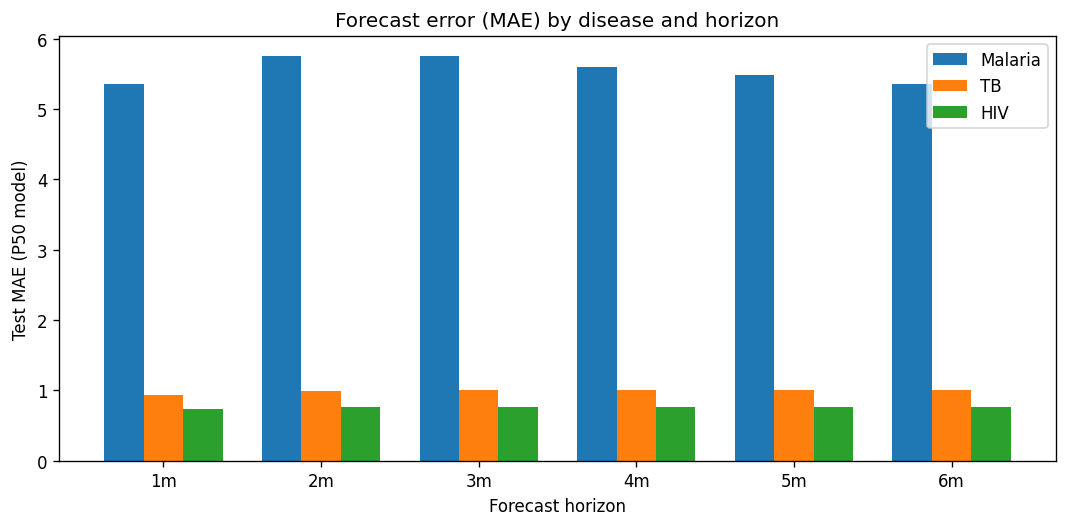

In [11]:
# 8b. Graph: MAE by disease across horizons (bar chart)
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.25
horizons_sorted = sorted(metrics_df['horizon_months'].unique())
x = np.arange(len(horizons_sorted))
for i, disease in enumerate(['Malaria', 'TB', 'HIV']):
    sub = metrics_df[metrics_df.disease == disease].set_index('horizon_months').loc[horizons_sorted]
    ax.bar(x + i * width, sub['MAE (P50)'], width=width, label=disease)
ax.set_xticks(x + width)
ax.set_xticklabels([f'{h}m' for h in horizons_sorted])
ax.set_xlabel('Forecast horizon')
ax.set_ylabel('Test MAE (P50 model)')
ax.set_title('Forecast error (MAE) by disease and horizon')
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "06_mae_by_disease_horizon.png")
plt.show()


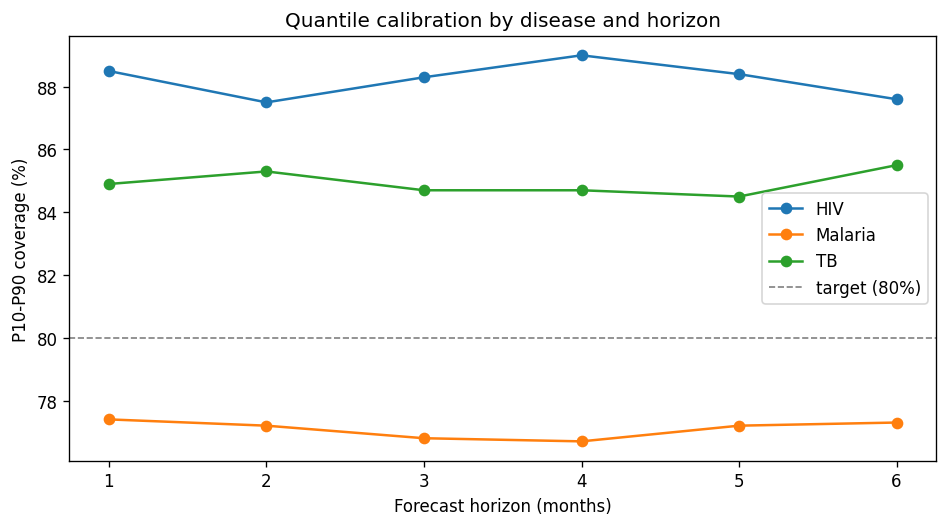

In [12]:
# 8c. Graph: calibration -- P10-P90 coverage vs the 80% target
# --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))
for disease, sub in metrics_df.groupby('disease'):
    sub = sub.sort_values('horizon_months')
    ax.plot(sub['horizon_months'], sub['P10-P90 coverage %'], marker='o', label=disease)
ax.axhline(80, color='gray', linestyle='--', linewidth=1, label='target (80%)')
ax.set_xlabel('Forecast horizon (months)')
ax.set_ylabel('P10-P90 coverage (%)')
ax.set_title('Quantile calibration by disease and horizon')
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "07_calibration_by_horizon.png")
plt.show()


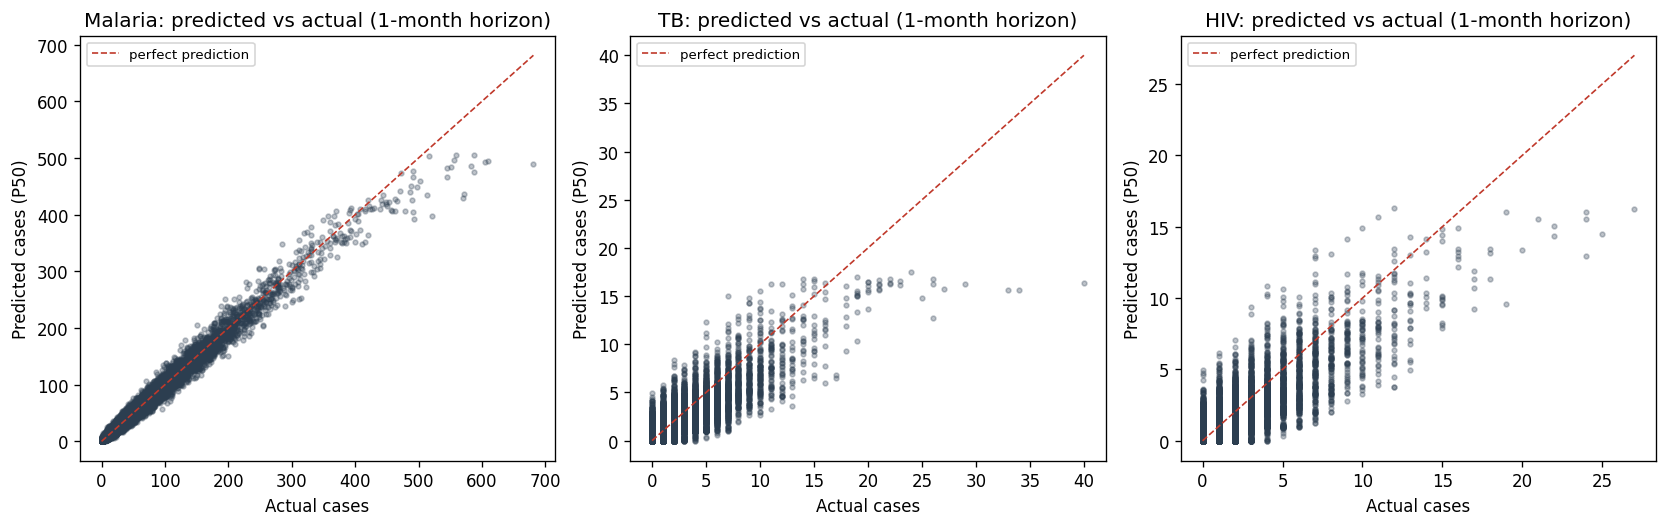

In [13]:
# 8d. Graph: predicted (P50) vs actual cases, 1-month horizon, one panel per disease
# ---------------------------------------------------------------------------------------
h1 = test_predictions[test_predictions.horizon == 1]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, disease in zip(axes, ['Malaria', 'TB', 'HIV']):
    sub = h1[h1.disease == disease]
    ax.scatter(sub['actual'], sub['pred_p50'], s=8, alpha=0.3, color='#2c3e50')
    lim = max(sub['actual'].max(), sub['pred_p50'].max())
    ax.plot([0, lim], [0, lim], color='#c0392b', linewidth=1, linestyle='--', label='perfect prediction')
    ax.set_title(f'{disease}: predicted vs actual (1-month horizon)')
    ax.set_xlabel('Actual cases')
    ax.set_ylabel('Predicted cases (P50)')
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(CHART_DIR / "08_predicted_vs_actual.png")
plt.show()


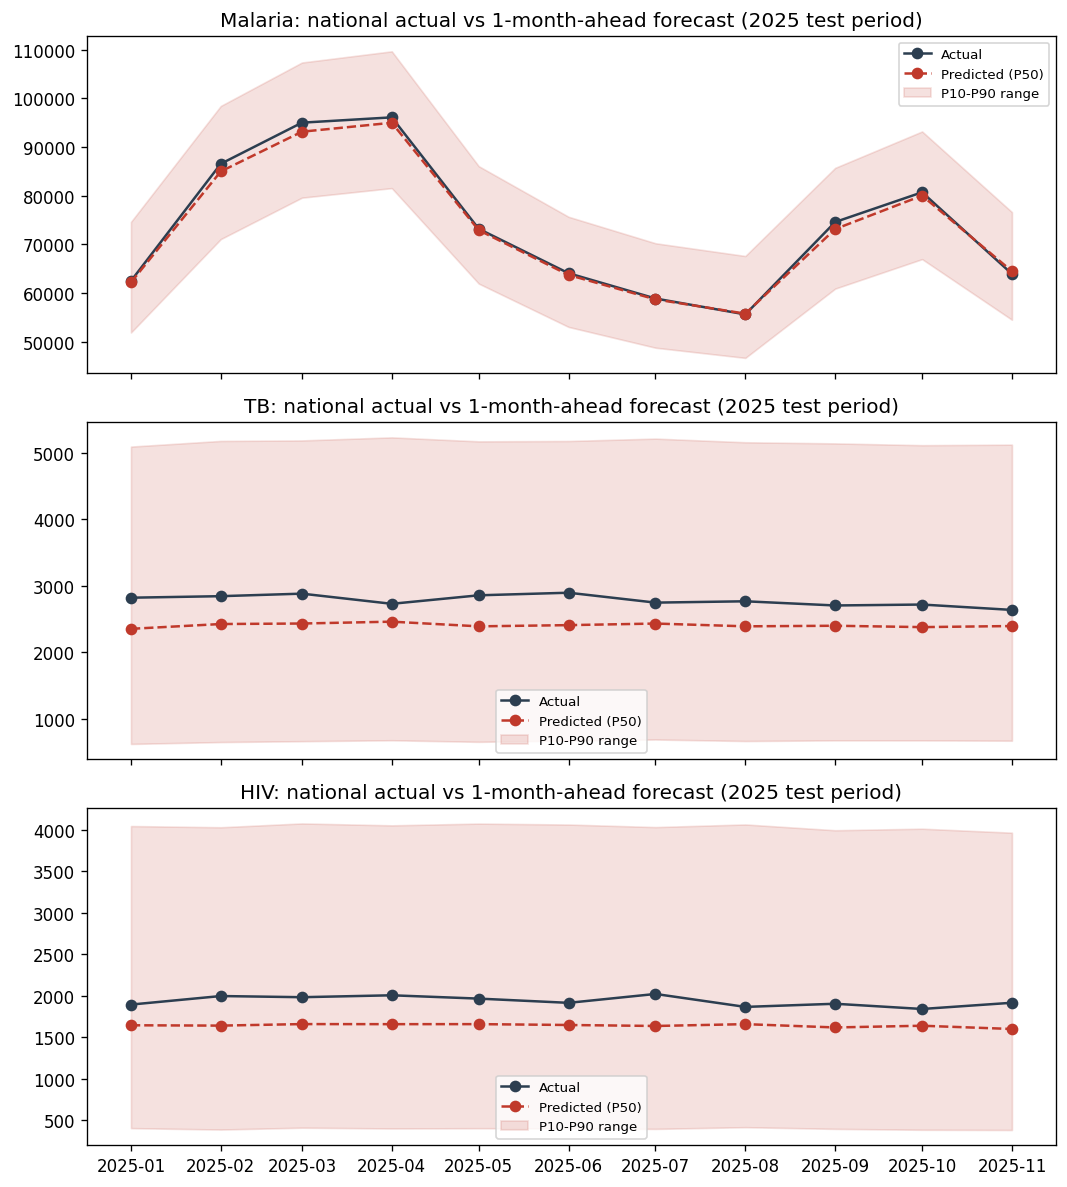

In [14]:
# 8e. Graph: actual vs forecast (P50 + P10-P90 band) over the 2025 test period
# ----------------------------------------------------------------------------------
# Aggregated to national level per disease so the trend is readable.
national_test = test_predictions[test_predictions.horizon == 1].groupby(['month', 'disease']).agg(
    actual=('actual', 'sum'), pred_p10=('pred_p10', 'sum'),
    pred_p50=('pred_p50', 'sum'), pred_p90=('pred_p90', 'sum')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
for ax, disease in zip(axes, ['Malaria', 'TB', 'HIV']):
    sub = national_test[national_test.disease == disease].sort_values('month')
    ax.plot(sub['month'], sub['actual'], marker='o', label='Actual', color='#2c3e50')
    ax.plot(sub['month'], sub['pred_p50'], marker='o', linestyle='--', label='Predicted (P50)', color='#c0392b')
    ax.fill_between(sub['month'], sub['pred_p10'], sub['pred_p90'], color='#c0392b', alpha=0.15, label='P10-P90 range')
    ax.set_title(f'{disease}: national actual vs 1-month-ahead forecast (2025 test period)')
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(CHART_DIR / "09_actual_vs_forecast_timeseries.png")
plt.show()


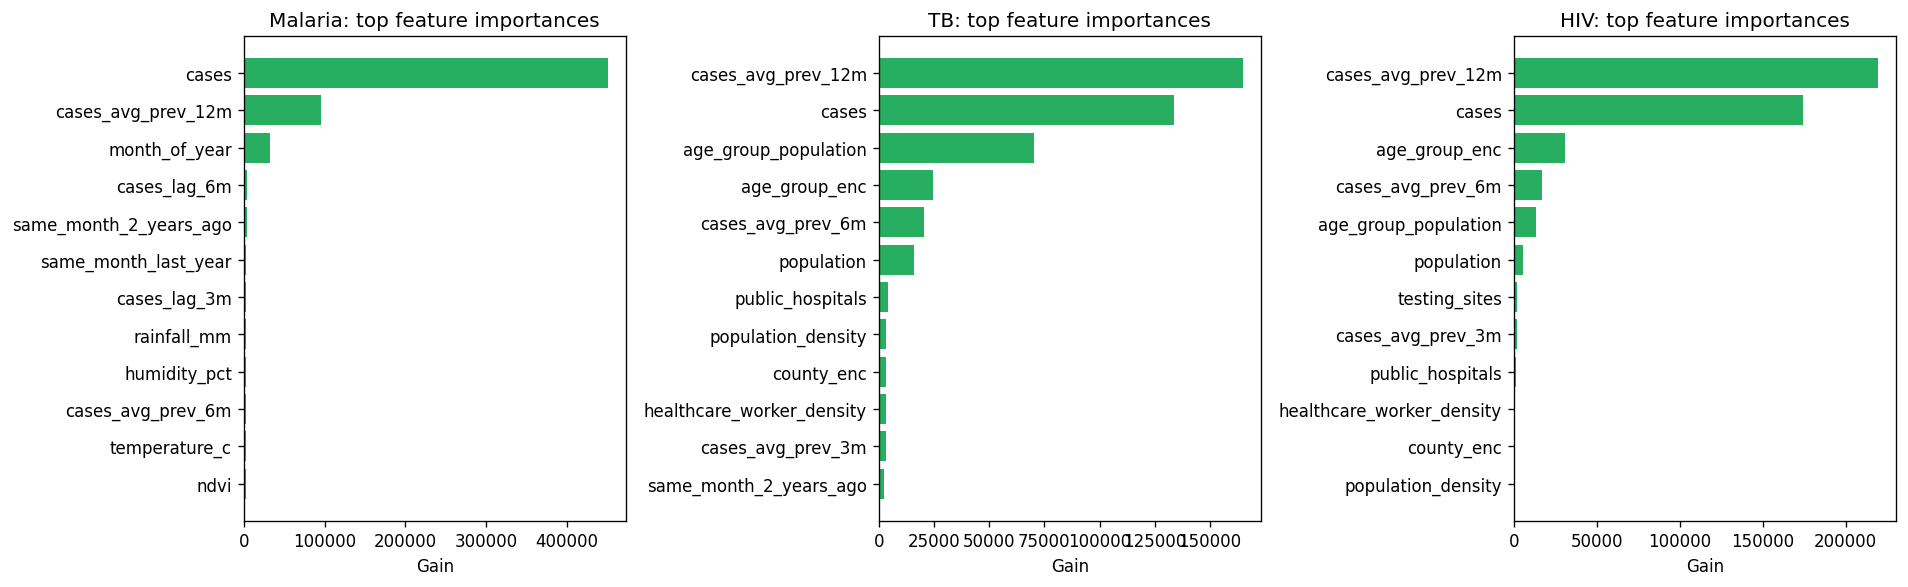

In [15]:
# 8f. Graph: feature importance per disease (1-month horizon, P50 model)
# ----------------------------------------------------------------------------
# Shows which features each disease's model actually relies on -- useful
# both as a sanity check (do climate features matter for Malaria as
# expected?) and for the project write-up.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, disease in zip(axes, ['Malaria', 'TB', 'HIV']):
    booster = trained_boosters[disease]
    importance = pd.Series(booster.feature_importance(importance_type='gain'),
                            index=booster.feature_name()).sort_values(ascending=True).tail(12)
    ax.barh(importance.index, importance.values, color='#27ae60')
    ax.set_title(f'{disease}: top feature importances')
    ax.set_xlabel('Gain')
fig.tight_layout()
fig.savefig(CHART_DIR / "10_feature_importance.png")
plt.show()


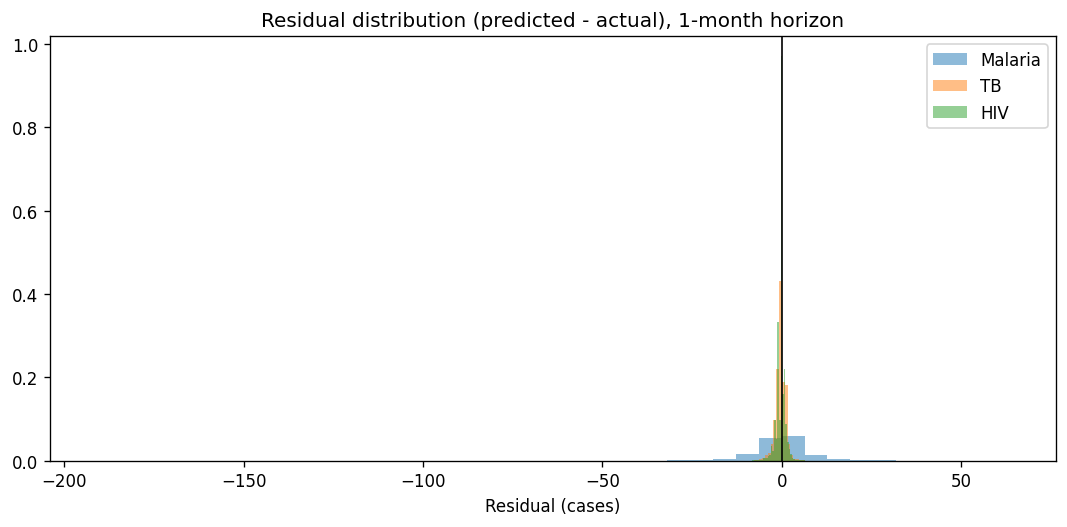

All evaluation graphs saved to /content/drive/MyDrive/SIP_AB/charts
Evaluation metrics table saved to /content/drive/MyDrive/SIP_AB/models/evaluation_metrics_table.csv


In [16]:
# 8g. Graph: residual distribution per disease (1-month horizon)
# --------------------------------------------------------------------
# Residuals centered near 0 with no strong skew indicate a well-behaved
# model. A residual consistently above/below 0 would indicate systematic
# over- or under-forecasting for that disease.

fig, ax = plt.subplots(figsize=(9, 4.5))
for disease in ['Malaria', 'TB', 'HIV']:
    sub = h1[h1.disease == disease]
    residuals = sub['pred_p50'] - sub['actual']
    ax.hist(residuals, bins=40, alpha=0.5, label=disease, density=True)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Residual distribution (predicted - actual), 1-month horizon')
ax.set_xlabel('Residual (cases)')
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "11_residual_distribution.png")
plt.show()

print("All evaluation graphs saved to", CHART_DIR)
print("Evaluation metrics table saved to", MODEL_DIR / "evaluation_metrics_table.csv")


In [17]:
# 9. Inference function
# ------------------------
# Given a county + disease + age group, this loads the saved models and
# returns a forecast table: expected cases (P50), the P10-P90 range, and
# the % change vs the most recently known month -- for each horizon you ask for.
#
# It uses the LATEST available row for that county/disease/age_group as the
# "current state" (its lag/rolling/climate features), which is exactly what
# your backend will do too: pull the latest known features, then call the
# saved models directly. No need to re-run training in the backend.

def forecast(county, disease, age_group, horizons=(1, 2, 3, 6)):
    grp = df[(df['county'] == county) & (df['disease'] == disease) & (df['age_group'] == age_group)]
    if grp.empty:
        raise ValueError(f"No data found for {county} / {disease} / {age_group}")

    latest = grp.sort_values('month').iloc[[-1]]     # most recent known month
    features = DISEASE_FEATURES[disease]
    X = latest[features]
    base_month = latest['month'].iloc[0]
    base_cases = latest['cases'].iloc[0]

    results = []
    for h in horizons:
        preds = {}
        for name in QUANTILES:
            model_path = MODEL_DIR / f"{disease}_h{h}_{name}.txt"
            booster = lgb.Booster(model_file=str(model_path))
            preds[name] = max(0.0, float(booster.predict(X)[0]))   # cases can't be negative

        pct_change = ((preds['p50'] - base_cases) / base_cases * 100) if base_cases > 0 else None

        results.append({
            'target_month': (base_month + pd.DateOffset(months=h)).strftime('%Y-%m'),
            'horizon_months': h,
            'disease': disease,
            'county': county,
            'age_group': age_group,
            'p10_cases': round(preds['p10'], 1),
            'p50_cases': round(preds['p50'], 1),   # <- headline "expected cases" number
            'p90_cases': round(preds['p90'], 1),
            'pct_change_vs_last_known': round(pct_change, 1) if pct_change is not None else None,
        })
    return pd.DataFrame(results)

# Example: forecast malaria cases for children (0-4) in Kisumu, 1/2/3/6 months out
example = forecast(county="Kisumu", disease="Malaria", age_group="0-4", horizons=[1, 2, 3, 6])
display(example)


,target_month,horizon_months,disease,county,age_group,p10_cases,p50_cases,p90_cases,pct_change_vs_last_known
0,2026-01,1,Malaria,Kisumu,0-4,22.4,28.0,34.4,-12.6
1,2026-02,2,Malaria,Kisumu,0-4,21.8,28.1,35.6,-12.2
2,2026-03,3,Malaria,Kisumu,0-4,31.7,38.6,46.8,20.5
3,2026-06,6,Malaria,Kisumu,0-4,24.5,31.6,37.2,-1.1


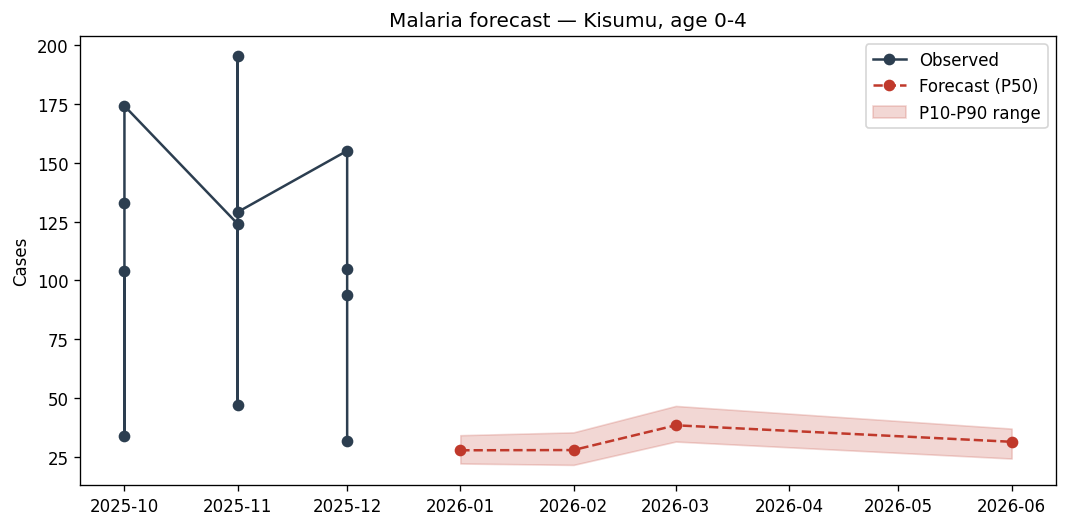

In [18]:
# 10. Visualize a forecast with its uncertainty band
# -------------------------------------------------------
# Plots recent history plus the P10-P90 forecast range for the horizons
# above -- this is the kind of chart your dashboard would show per county.

def plot_forecast(county, disease, age_group, horizons=(1, 2, 3, 6), months_history=12):
    hist = df[(df['county'] == county) & (df['disease'] == disease) & (df['age_group'] == age_group)]
    hist = hist.sort_values('month').tail(months_history)
    fc = forecast(county, disease, age_group, horizons)
    fc_dates = pd.to_datetime(fc['target_month'])

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(hist['month'], hist['cases'], marker='o', label='Observed', color='#2c3e50')
    ax.plot(fc_dates, fc['p50_cases'], marker='o', linestyle='--', label='Forecast (P50)', color='#c0392b')
    ax.fill_between(fc_dates, fc['p10_cases'], fc['p90_cases'], color='#c0392b', alpha=0.2, label='P10-P90 range')
    ax.set_title(f'{disease} forecast — {county}, age {age_group}')
    ax.set_ylabel('Cases')
    ax.legend()
    fig.tight_layout()
    fig.savefig(CHART_DIR / f"forecast_{county}_{disease}_{age_group}.png".replace(' ', '_'))
    plt.show()

plot_forecast("Kisumu", "Malaria", "0-4")


## 11. Export forecast data for the dashboard

Your Next.js dashboard reads a single JSON file shaped exactly like the
`DiseaseMonthlyData` type in `lib/types.ts`:

```
{
  meta: { isSynthetic, note, currentMonth, historicalMonths, forecastMonths, generatedAt },
  series: { [diseaseId]: { [regionId]: MonthlyPoint[] } }
}
```

Two gaps to close before we can build that:

1. **Region, not county.** The dashboard groups by Kenya's 8 former
   provinces (`nairobi`, `central`, `coast`, `eastern`, `northEastern`,
   `nyanza`, `riftValley`, `western`), not the 47 counties the models were
   trained on. We map each county to its region and sum.
2. **One number per disease/region/month, not per age group.** The models
   forecast per county + age group + facility group. We sum across all of
   those within a region to get the region-level total the dashboard shows.

The cells below build that mapping, aggregate history + forecasts, and
write `disease-monthly-data.json` to `DASHBOARD_DIR`. Copy that one file
into your Next.js project (e.g. `data/disease-monthly-data.json`) — the
`lib/data/store.ts` module provided alongside this notebook reads it
directly.


In [19]:
# 11a. County -> region mapping, and disease-id mapping
# -----------------------------------------------------------
# Kenya's 47 counties map cleanly onto the 8 former provinces, which is
# the region grouping the dashboard uses. Verified against every county
# name actually present in this dataset (see assertion below).

COUNTY_TO_REGION = {
    'Nairobi City': 'nairobi',
    'Kiambu': 'central', "Murang'a": 'central', 'Nyeri': 'central', 'Kirinyaga': 'central', 'Nyandarua': 'central',
    'Mombasa': 'coast', 'Kwale': 'coast', 'Kilifi': 'coast', 'Tana River': 'coast', 'Lamu': 'coast', 'Taita Taveta': 'coast',
    'Machakos': 'eastern', 'Kitui': 'eastern', 'Makueni': 'eastern', 'Embu': 'eastern', 'Tharaka Nithi': 'eastern',
    'Meru': 'eastern', 'Isiolo': 'eastern', 'Marsabit': 'eastern',
    'Garissa': 'northEastern', 'Wajir': 'northEastern', 'Mandera': 'northEastern',
    'Kisumu': 'nyanza', 'Siaya': 'nyanza', 'Homa Bay': 'nyanza', 'Migori': 'nyanza', 'Kisii': 'nyanza', 'Nyamira': 'nyanza',
    'Nakuru': 'riftValley', 'Uasin Gishu': 'riftValley', 'Trans Nzoia': 'riftValley', 'Kericho': 'riftValley',
    'Bomet': 'riftValley', 'Nandi': 'riftValley', 'Baringo': 'riftValley', 'Laikipia': 'riftValley', 'Samburu': 'riftValley',
    'Turkana': 'riftValley', 'West Pokot': 'riftValley', 'Elgeyo Marakwet': 'riftValley', 'Narok': 'riftValley', 'Kajiado': 'riftValley',
    'Kakamega': 'western', 'Bungoma': 'western', 'Busia': 'western', 'Vihiga': 'western',
}
DISEASE_ID_MAP = {'Malaria': 'malaria', 'TB': 'tb', 'HIV': 'hiv'}   # CSV name -> dashboard DiseaseId
REGION_IDS = ['nairobi', 'central', 'coast', 'eastern', 'northEastern', 'nyanza', 'riftValley', 'western']
HISTORY_MONTHS_TO_EXPORT = 24     # how many recent months of history to include in the chart

df['region'] = df['county'].map(COUNTY_TO_REGION)
df['disease_id'] = df['disease'].map(DISEASE_ID_MAP)

assert df['region'].isna().sum() == 0, "Some counties didn't map to a region -- check COUNTY_TO_REGION"
assert df['disease_id'].isna().sum() == 0, "Some disease values didn't map -- check DISEASE_ID_MAP"
print("All counties and diseases mapped successfully.")


All counties and diseases mapped successfully.


In [20]:
# 11b. Aggregate historical cases to region x disease x month
# -----------------------------------------------------------------
last_month = df['month'].max()
all_months_sorted = sorted(df['month'].unique())
historical_months_dt = all_months_sorted[-HISTORY_MONTHS_TO_EXPORT:]
historical_months = [pd.Timestamp(m).strftime('%Y-%m') for m in historical_months_dt]
forecast_months = [(pd.Timestamp(last_month) + pd.DateOffset(months=h)).strftime('%Y-%m') for h in HORIZONS]

hist_slice = df[df['month'].isin(historical_months_dt)]
hist_totals = hist_slice.groupby(['disease_id', 'region', 'month'])['cases'].sum().reset_index()

# series[disease_id][region_id] -> list of MonthlyPoint dicts (historical, then forecast)
series = {d: {r: [] for r in REGION_IDS} for d in DISEASE_ID_MAP.values()}

for _, row in hist_totals.iterrows():
    series[row['disease_id']][row['region']].append({
        "month": pd.Timestamp(row['month']).strftime('%Y-%m'),
        "cases": int(round(row['cases'])),
        "type": "historical",
    })

for d in series:
    for r in series[d]:
        series[d][r].sort(key=lambda p: p['month'])

print(f"Historical window: {historical_months[0]} to {historical_months[-1]} ({len(historical_months)} months)")
print(f"Forecast window:   {forecast_months[0]} to {forecast_months[-1]} ({len(forecast_months)} months)")


Historical window: 2024-01 to 2025-12 (24 months)
Forecast window:   2026-01 to 2026-06 (6 months)


In [21]:
# 11c. Aggregate forecasts to region x disease x month
# -----------------------------------------------------------
# For each disease and horizon we batch-predict on the latest known row for
# EVERY (county, age_group, facility_group) combo at once (fast: one predict
# call per model instead of one per county), then sum up to county level,
# then up to region level -- exactly mirroring how `forecast()` works for a
# single county, just done for all of them together.

county_to_region_series = df[['county', 'region']].drop_duplicates().set_index('county')['region']

for disease_name, disease_id in DISEASE_ID_MAP.items():
    sub = df[df.disease == disease_name]
    features = DISEASE_FEATURES[disease_name]
    latest = sub[sub['month'] == last_month].copy()   # one row per county/age_group/facility_group
    X_latest = latest[features]

    for h in HORIZONS:
        target_month = (pd.Timestamp(last_month) + pd.DateOffset(months=h)).strftime('%Y-%m')
        preds = {}
        for name in QUANTILES:
            booster = lgb.Booster(model_file=str(MODEL_DIR / f"{disease_name}_h{h}_{name}.txt"))
            preds[name] = np.maximum(0, booster.predict(X_latest))   # cases can't be negative

        tmp = latest[['county']].copy()
        tmp['p10'], tmp['p50'], tmp['p90'] = preds['p10'], preds['p50'], preds['p90']
        county_totals = tmp.groupby('county')[['p10', 'p50', 'p90']].sum()
        county_totals['region'] = county_to_region_series
        region_totals = county_totals.groupby('region')[['p10', 'p50', 'p90']].sum()

        for region_id in REGION_IDS:
            r = region_totals.loc[region_id]
            series[disease_id][region_id].append({
                "month": target_month,
                "cases": int(round(r['p50'])),   # headline number
                "low": int(round(r['p10'])),
                "high": int(round(r['p90'])),
                "type": "forecast",
            })

print("Forecast aggregation done for all diseases and horizons.")


Forecast aggregation done for all diseases and horizons.


In [22]:
# 11d. Assemble and save disease-monthly-data.json
# -----------------------------------------------------------
import datetime as _dt

dashboard_data = {
    "meta": {
        "isSynthetic": True,
        "note": "Generated from a synthetic training dataset (2018-2025); replace with verified Kenyan health data when available.",
        "currentMonth": historical_months[-1],
        "historicalMonths": historical_months,
        "forecastMonths": forecast_months,
        "generatedAt": _dt.datetime.now(_dt.timezone.utc).isoformat(),
    },
    "series": series,
}

out_path = DASHBOARD_DIR / "disease-monthly-data.json"
with open(out_path, "w") as f:
    json.dump(dashboard_data, f, indent=2)

print("Saved:", out_path)
print("\nPreview -- Malaria / Nairobi, last 3 historical + all forecast points:")
print(json.dumps(series['malaria']['nairobi'][-(3 + len(HORIZONS)):], indent=2))


Saved: /content/drive/MyDrive/SIP_AB/dashboard_export/disease-monthly-data.json

Preview -- Malaria / Nairobi, last 3 historical + all forecast points:
[
  {
    "month": "2025-10",
    "cases": 4991,
    "type": "historical"
  },
  {
    "month": "2025-11",
    "cases": 5554,
    "type": "historical"
  },
  {
    "month": "2025-12",
    "cases": 4338,
    "type": "historical"
  },
  {
    "month": "2026-01",
    "cases": 4088,
    "low": 3673,
    "high": 4564,
    "type": "forecast"
  },
  {
    "month": "2026-02",
    "cases": 4221,
    "low": 3787,
    "high": 4725,
    "type": "forecast"
  },
  {
    "month": "2026-03",
    "cases": 5710,
    "low": 4907,
    "high": 6347,
    "type": "forecast"
  },
  {
    "month": "2026-04",
    "cases": 6268,
    "low": 5485,
    "high": 6984,
    "type": "forecast"
  },
  {
    "month": "2026-05",
    "cases": 6393,
    "low": 5542,
    "high": 7056,
    "type": "forecast"
  },
  {
    "month": "2026-06",
    "cases": 5113,
    "low": 4559,
 

In [ ]:
# 11e. Export latest feature snapshot for live backend inference
# -----------------------------------------------------------------
# backend/predictor.py can serve forecasts two ways: from this notebook's
# own disease-monthly-data.json export (works today, no extra files
# needed), or by loading the saved LightGBM boosters above and predicting
# on demand. The second path needs one more thing this notebook hasn't
# saved yet: the LATEST known feature row per
# county/disease/age_group/facility_group -- forecast() (section 9) needs
# those same features to call the boosters. This cell saves exactly that,
# tagged with each county's region, so the backend never needs the raw
# multi-year training CSV -- only MODEL_DIR plus this one file.

def _to_native(v):
    if pd.isna(v):
        return None
    if hasattr(v, "item"):
        return v.item()
    return v

latest_rows = []
for disease_name, disease_id in DISEASE_ID_MAP.items():
    sub = df[df.disease == disease_name]
    features = DISEASE_FEATURES[disease_name]
    latest = sub[sub['month'] == last_month].copy()

    for _, row in latest.iterrows():
        latest_rows.append({
            "county": row['county'],
            "region": row['region'],
            "disease_name": disease_name,
            "disease_id": disease_id,
            "age_group": row['age_group'],
            "target_months": [
                (pd.Timestamp(last_month) + pd.DateOffset(months=h)).strftime('%Y-%m')
                for h in HORIZONS
            ],
            "features": {feat: _to_native(row[feat]) for feat in features},
        })

with open(MODEL_DIR / "latest_features.json", "w") as f:
    json.dump(latest_rows, f, indent=2)

print(f"Saved {len(latest_rows)} latest-feature rows to", MODEL_DIR / "latest_features.json")
print("MODEL_DIR now contains everything backend/predictor.py needs for live inference:")
print(sorted(p.name for p in MODEL_DIR.glob('*.json')))



## Next steps

- The backend only needs `MODEL_DIR` (54 `.txt` model files + `label_maps.json`
  + `feature_sets.json`) if you want on-demand predictions later — for the
  dashboard itself, only `disease-monthly-data.json` from `DASHBOARD_DIR`
  is needed.
- Copy `disease-monthly-data.json` into your Next.js project and drop in
  the `lib/data/store.ts`, updated `lib/data/derive.ts`, and
  `app/api/forecast/route.ts` files provided alongside this notebook.
- When real Kenyan data becomes available, re-run this notebook unchanged
  against the new CSV, then re-copy the freshly generated JSON — everything
  downstream (store/derive/API/UI) stays the same.